# Aplikacja DnoOka — porównanie trzech metod

Wymaga wcześniejszego uruchomienia `01_baseline.ipynb`, `02_classical_ml.ipynb`, `03_deep_learning.ipynb` (artefakty w `results/` i `models/`). `ipywidgets` jest opcjonalny.

## 1. Środowisko i modele

In [1]:
import sys, time, traceback
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print('[INFO] ipywidgets nie jest zainstalowany.')

from src import io_utils, metrics, visualize
from src import baseline, classical_ml, unet
from src.config import TEST_IMAGES, MODELS_DIR, REPORT_DIR

# device wyznaczamy bezwarunkowo — potrzebny i dla load_model, i dla predict_unet,
# i nie powinien zależeć od obecności pliku unet.pt.
device = unet.get_device()

### Wczytanie modeli

In [2]:
rf_path = MODELS_DIR / 'rf.joblib'
unet_path = MODELS_DIR / 'unet.pt'

if not rf_path.exists():
    print(f'[WARN] {rf_path} nie znaleziony — uruchom 02_classical_ml.ipynb')
    rf_model = None
else:
    rf_model = classical_ml.load_model(rf_path)
    print(f'RF loaded:    {rf_path}')

if not unet_path.exists():
    print(f'[WARN] {unet_path} nie znaleziony — uruchom 03_deep_learning.ipynb')
    unet_model = None
else:
    unet_model = unet.load_model(unet_path, device=device)
    print(f'U-Net loaded: {unet_path}  ({device})')

RF loaded:    /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/models/rf.joblib
U-Net loaded: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/models/unet.pt  (mps)


### Wspólne API predykcji

In [3]:
# Parametry predykcji wyniesione tutaj — te same wartości używane
# w etapach 1-3 i zapisane w results/*.json dla reprodukowalności.
RF_STRIDE   = 2
UNET_TILE   = 256
UNET_OVER   = 32
UNET_THR    = 0.5

def predict_baseline(rgb, fov):
    return baseline.predict_mask(rgb, fov)

def predict_rf(rgb, fov):
    if rf_model is None:
        raise RuntimeError('rf_model nie wczytany — uruchom 02_classical_ml.ipynb')
    return classical_ml.predict_mask(rf_model, rgb, fov, stride=RF_STRIDE, progress=False)

def predict_unet(rgb, fov):
    if unet_model is None:
        raise RuntimeError('unet_model nie wczytany — uruchom 03_deep_learning.ipynb')
    return unet.predict_mask(
        unet_model, rgb, fov, device=device,
        tile_size=UNET_TILE, overlap=UNET_OVER, threshold=UNET_THR,
    )

PREDICTORS = {
    'baseline (Frangi)':  predict_baseline,
    'random_forest':      predict_rf,
    'unet':               predict_unet,
}
COLORS = {
    'baseline (Frangi)':  (255, 0, 0),       # czerwony
    'random_forest':      (0, 200, 0),       # zielony
    'unet':               (0, 100, 255),     # niebieski
}
print('Dostępne predictors:', list(PREDICTORS.keys()))

Dostępne predictors: ['baseline (Frangi)', 'random_forest', 'unet']


### Cache predykcji

In [ ]:
# Klucz: (image_id, method) -> uint8 mask. Wypełniany w trakcie obliczeń.
pred_cache: dict[tuple[str, str], np.ndarray] = {}

def cached_predict(image_id: str, method: str):
    """Zwraca (img, gt, fv, pred) z cache na masce predykcji."""
    img, gt, fv = io_utils.load_triplet(image_id)
    key = (image_id, method)
    if key not in pred_cache:
        pred_cache[key] = PREDICTORS[method](img, fv)
    return img, gt, fv, pred_cache[key]

## 2. Aplikacja interaktywna

Wybór obrazu + metody -> wynik + metryki.

In [ ]:
if HAVE_WIDGETS:
    image_dd = widgets.Dropdown(options=list(TEST_IMAGES), description='Image:')
    method_dd = widgets.Dropdown(options=list(PREDICTORS.keys()), description='Method:')
    run_btn  = widgets.Button(description='Run', button_style='primary')
    out_area = widgets.Output()

    def on_run_clicked(_):
        # Blokujemy przycisk, żeby uniknąć równoległych uruchomień.
        run_btn.disabled = True
        original_desc = run_btn.description
        run_btn.description = 'Running...'
        out_area.clear_output(wait=True)
        try:
            with out_area:
                image_id = image_dd.value
                method = method_dd.value
                cached = (image_id, method) in pred_cache
                print(f'-> {method} on {image_id} ' + ('(cached)' if cached else '...'))
                t0 = time.time()
                try:
                    img, gt, fv, pred = cached_predict(image_id, method)
                except Exception as e:
                    print(f'Błąd: {e}')
                    traceback.print_exc()
                    return
                elapsed = time.time() - t0
                m = metrics.compute_metrics(pred, gt, fv)
                print(f'  zajęło {elapsed:.1f}s')
                print()
                for k in ['accuracy', 'sensitivity', 'specificity',
                          'precision', 'g_mean', 'balanced_accuracy']:
                    print(f'  {k:20s} = {m[k]:.4f}')
                fig = visualize.compare_grid([
                    ('Original', img),
                    ('Ground truth', gt * 255),
                    (f'{method} prediction', pred * 255),
                    ('Overlay', visualize.overlay(img, pred, color=COLORS[method], alpha=0.6)),
                ], ncols=4, suptitle=f'{image_id} — {method}', figsize_per_panel=(4, 4))
                plt.show()
        finally:
            run_btn.disabled = False
            run_btn.description = original_desc

    run_btn.on_click(on_run_clicked)
    display(widgets.HBox([image_dd, method_dd, run_btn]), out_area)
else:
    print('Sekcja 2 pominięta (brak ipywidgets).')

Output()

## 3. Zbiorcze porównanie trzech metod

In [6]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it

rows = []          # [{image, method, accuracy, ...}]
skipped = []       # tu odkładamy (image_id, method, reason) dla nieobliczonych

for image_id in tqdm(TEST_IMAGES, desc='images'):
    for method in PREDICTORS:
        try:
            img, gt, fv, pred = cached_predict(image_id, method)
        except RuntimeError as e:
            skipped.append((image_id, method, str(e)))
            continue
        m = metrics.compute_metrics(pred, gt, fv)
        rows.append({'image': image_id, 'method': method, **m})
        print(f'  {image_id:8s} {method:20s}  '
              f'acc={m["accuracy"]:.4f}  sens={m["sensitivity"]:.4f}  '
              f'spec={m["specificity"]:.4f}  g_mean={m["g_mean"]:.4f}')

if skipped:
    print('\nPominięte (model nie wczytany):')
    for image_id, method, reason in skipped:
        print(f'  {image_id}/{method}: {reason}')

df = pd.DataFrame(rows)
df.head()

images:   0%|          | 0/6 [00:00<?, ?it/s]

  14_h     baseline (Frangi)     acc=0.9024  sens=0.7379  spec=0.9213  g_mean=0.8245
  14_h     random_forest         acc=0.8890  sens=0.7817  spec=0.9014  g_mean=0.8394
  14_h     unet                  acc=0.9698  sens=0.8457  spec=0.9841  g_mean=0.9123


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:73: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_size)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:75: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, footprint=disk(closing_radius))


  15_h     baseline (Frangi)     acc=0.9364  sens=0.6595  spec=0.9648  g_mean=0.7977
  15_h     random_forest         acc=0.9245  sens=0.6709  spec=0.9504  g_mean=0.7985
  15_h     unet                  acc=0.9751  sens=0.7965  spec=0.9933  g_mean=0.8895


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:73: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_size)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:75: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, footprint=disk(closing_radius))


...

/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:73: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_size)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:75: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, footprint=disk(closing_radius))


  14_g     baseline (Frangi)     acc=0.9234  sens=0.6841  spec=0.9452  g_mean=0.8042
  14_g     random_forest         acc=0.9107  sens=0.6822  spec=0.9315  g_mean=0.7972
  14_g     unet                  acc=0.9599  sens=0.7780  spec=0.9765  g_mean=0.8716


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:73: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_size)
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:75: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  m = binary_closing(m, footprint=disk(closing_radius))


  15_g     baseline (Frangi)     acc=0.9292  sens=0.6537  spec=0.9553  g_mean=0.7903
  15_g     random_forest         acc=0.8355  sens=0.8432  spec=0.8347  g_mean=0.8389
  15_g     unet                  acc=0.9597  sens=0.8040  spec=0.9745  g_mean=0.8852


,image,method,accuracy,sensitivity,specificity,precision,g_mean,balanced_accuracy,arith_mean,tp,fp,tn,fn
0,14_h,baseline (Frangi),0.902357,0.737911,0.921308,0.519370,0.824526,0.829609,0.829609,526900.0,487598.0,5708668.0,187143.0
1,14_h,random_forest,0.889010,0.781741,0.901372,0.477367,0.839428,0.841557,0.841557,558197.0,611127.0,5585139.0,155846.0
2,14_h,unet,0.969820,0.845739,0.984119,0.859882,0.912309,0.914929,0.914929,603894.0,98405.0,6097861.0,110149.0
3,15_h,baseline (Frangi),0.936442,0.659492,0.964759,0.656763,0.797654,0.812126,0.812126,422896.0,221014.0,6050555.0,218349.0
4,15_h,random_forest,0.924517,0.670901,0.950448,0.580599,0.798534,0.810675,0.810675,430212.0,310768.0,5960801.0,211033.0


### 3.1 Średnie po metodach

In [7]:
summary = df.groupby('method')[
    ['accuracy', 'sensitivity', 'specificity', 'precision', 'g_mean', 'balanced_accuracy']
].agg(['mean', 'std']).round(4)
summary

accuracy         sensitivity         specificity          \
                      mean     std        mean     std        mean     std   
method                                                                       
baseline (Frangi)   0.9098  0.0244      0.6642  0.0463      0.9337  0.0272   
random_forest       0.8759  0.0377      0.7664  0.0752      0.8869  0.0485   
unet                0.9637  0.0070      0.7940  0.0342      0.9802  0.0074   

                  precision          g_mean         balanced_accuracy          
                       mean     std    mean     std              mean     std  
method                                                                         
baseline (Frangi)    0.5109  0.1125  0.7870  0.0296            0.7989  0.0268  
random_forest        0.4214  0.1072  0.8225  0.0206            0.8267  0.0158  
unet                 0.7970  0.0786  0.8821  0.0200            0.8871  0.0183

### 3.2 Tabela per-image × per-method

In [8]:
pivot = df.set_index(['image', 'method'])[
    ['accuracy', 'sensitivity', 'specificity', 'precision', 'g_mean', 'balanced_accuracy']
].round(4)
pivot

accuracy  sensitivity  specificity  precision  \
image method                                                             
14_h  baseline (Frangi)    0.9024       0.7379       0.9213     0.5194   
      random_forest        0.8890       0.7817       0.9014     0.4774   
      unet                 0.9698       0.8457       0.9841     0.8599   
15_h  baseline (Frangi)    0.9364       0.6595       0.9648     0.6568   
      random_forest        0.9245       0.6709       0.9504     0.5806   
      unet                 0.9751       0.7965       0.9933     0.9243   
14_dr baseline (Frangi)    0.8957       0.5961       0.9255     0.4428   
      random_forest        0.8564       0.7780       0.8642     0.3628   
      unet                 0.9574       0.7413       0.9789     0.7769   
15_dr baseline (Frangi)    0.8716       0.6539       0.8899     0.3324   
      random_forest        0.8394       0.8424       0.8391     0.3052   
      unet                 0.9603       0.7986       0.9739     0.7195   
14_g  baseline (Frangi)    0.9234       0.6841       0.9452     0.5326   
      random_forest        0.9107       0.6822       0.9315     0.4760   
      unet                 0.9599       0.7780       0.9765     0.7514   
15_g  baseline (Frangi)    0.9292       0.6537       0.9553     0.5815   
      random_forest        0.8355       0.8432       0.8347     0.3262   
      unet                 0.9597       0.8040       0.9745     0.7497   

                         g_mean  balanced_accuracy  
image method                                        
14_h  baseline (Frangi)  0.8245             0.8296  
      random_forest      0.8394             0.8416  
      unet               0.9123             0.9149  
15_h  baseline (Frangi)  0.7977             0.8121  
      random_forest      0.7985             0.8107  
      unet               0.8895             0.8949  
14_dr baseline (Frangi)  0.7428             0.7608  
      random_forest      0.8200             0.8211  
      unet               0.8518             0.8601  
15_dr baseline (Frangi)  0.7628             0.7719  
      random_forest      0.8408             0.8408  
      unet               0.8819             0.8862  
14_g  baseline (Frangi)  0.8042             0.8147  
      random_forest      0.7972             0.8069  
      unet               0.8716             0.8772  
15_g  baseline (Frangi)  0.7903             0.8045  
      random_forest      0.8389             0.8390  
      unet               0.8852             0.8893

### 3.3 Siatka wizualna: GT vs metody

Każda figura zapisywana do `report/figs/<image_id>.png`.

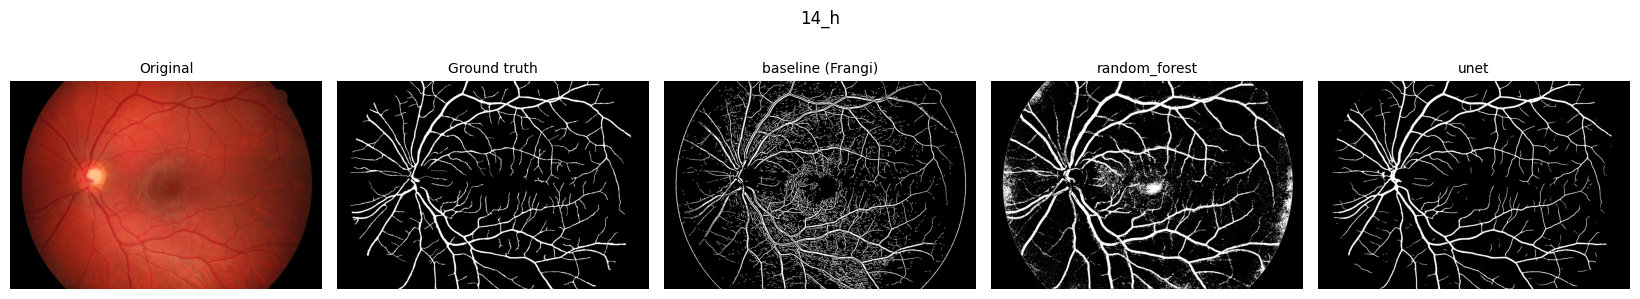

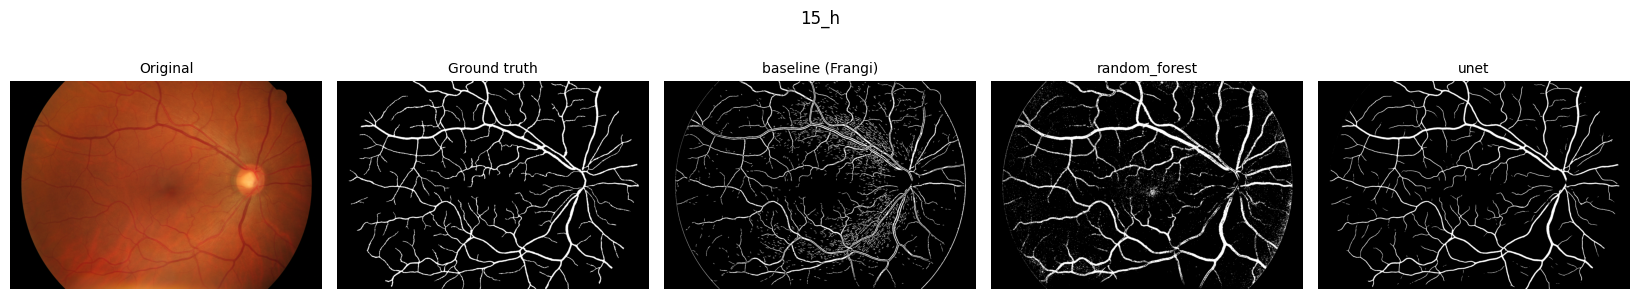

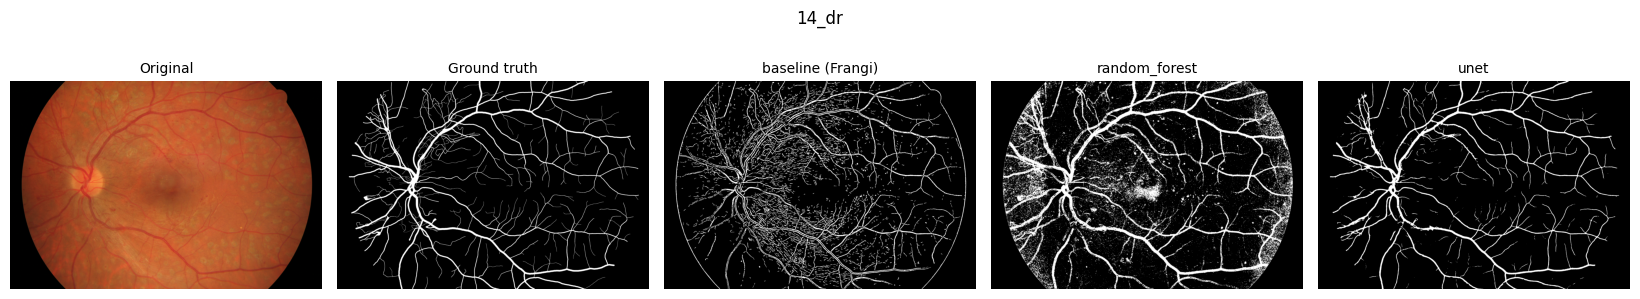

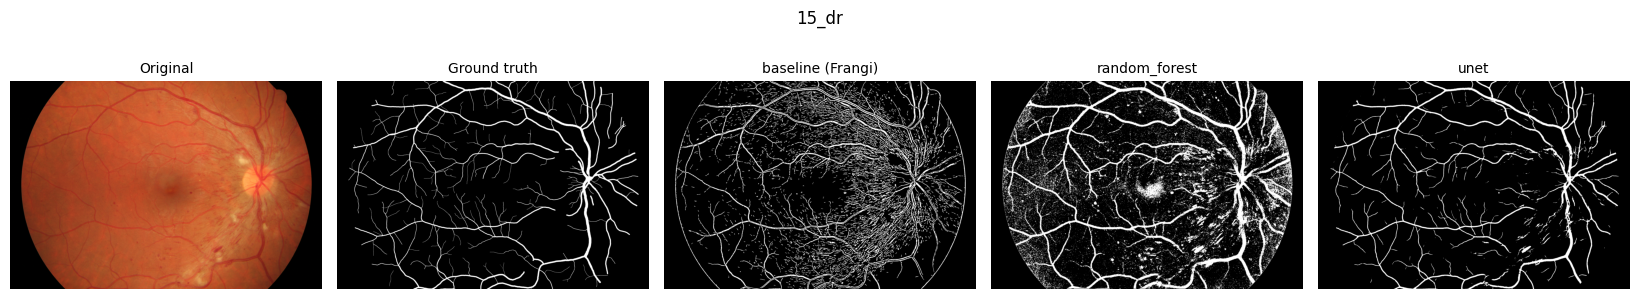

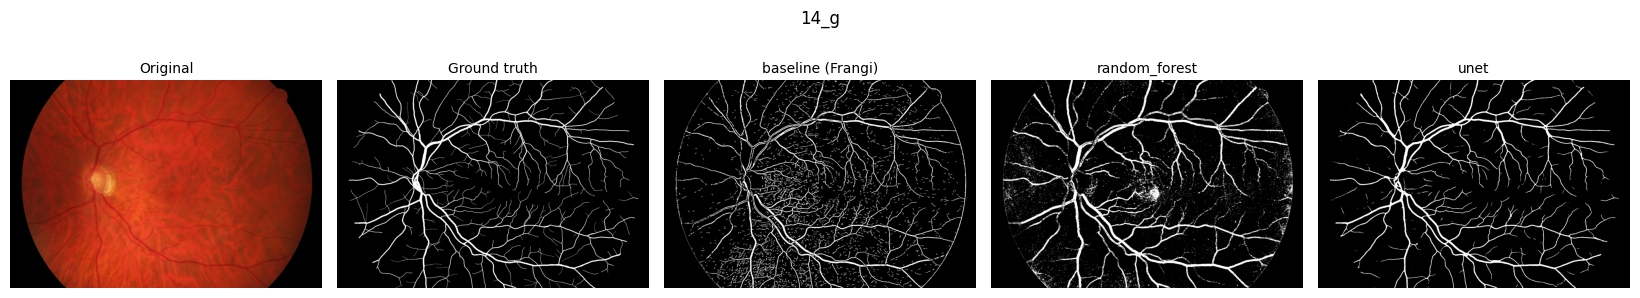

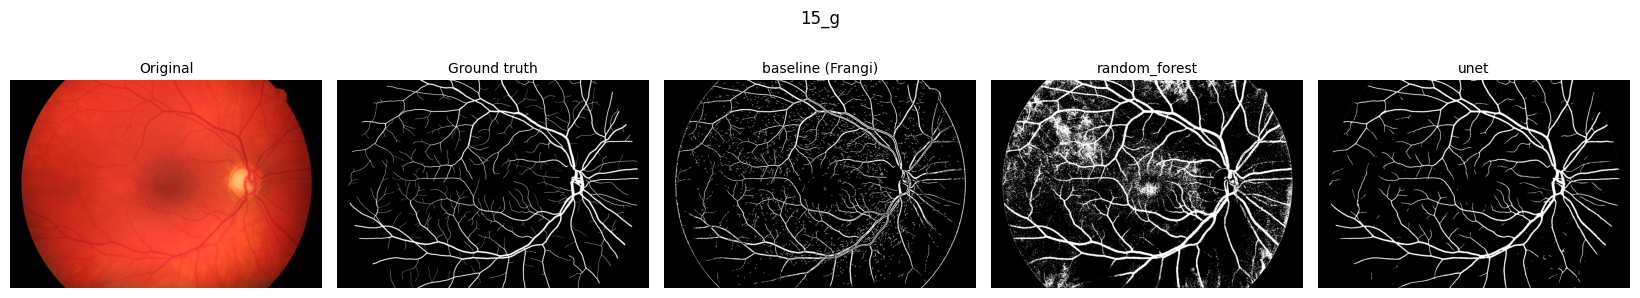


Obrazy zapisane w /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/report/figs


In [9]:
figs_dir = REPORT_DIR / 'figs'
figs_dir.mkdir(parents=True, exist_ok=True)
method_order = list(PREDICTORS.keys())

for image_id in TEST_IMAGES:
    img, gt, fv = io_utils.load_triplet(image_id)
    panels = [('Original', img), ('Ground truth', gt * 255)]
    for method in method_order:
        key = (image_id, method)
        if key in pred_cache:
            panels.append((method, pred_cache[key] * 255))
    fig = visualize.compare_grid(panels, ncols=len(panels),
                                 suptitle=image_id, figsize_per_panel=(3.3, 3.3))
    fig.savefig(figs_dir / f'{image_id}.png', dpi=120, bbox_inches='tight')
    plt.show()
print(f'\nObrazy zapisane w {figs_dir}')

### 3.4 Bar chart: średnie po metodach

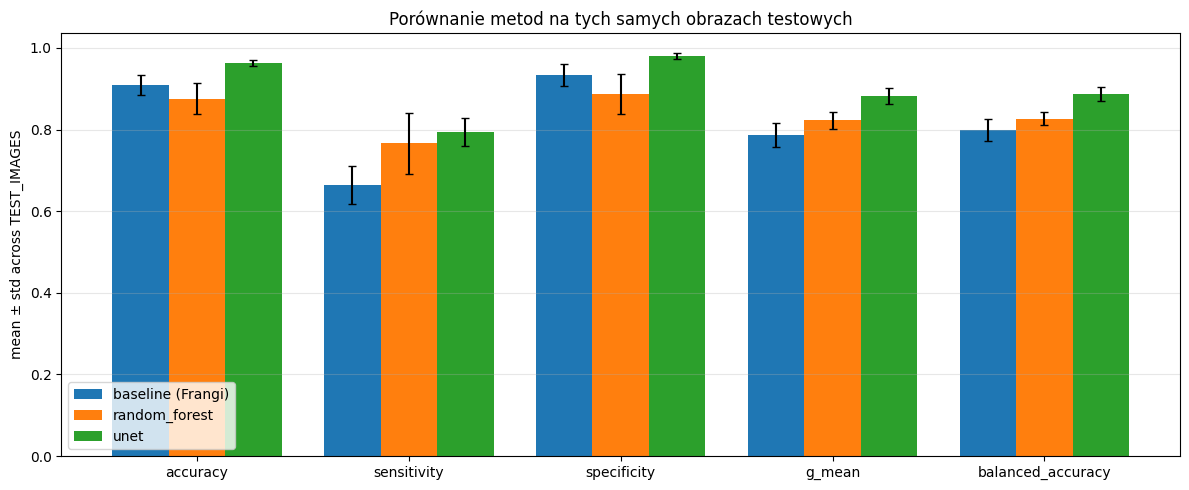

In [10]:
metric_keys = ['accuracy', 'sensitivity', 'specificity', 'g_mean', 'balanced_accuracy']
means = df.groupby('method')[metric_keys].mean()
stds  = df.groupby('method')[metric_keys].std()
n_methods = len(means.index)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metric_keys))
width = 0.8 / max(n_methods, 1)
for i, method in enumerate(means.index):
    # Centrujemy grupę słupków wokół każdego x — działa dla dowolnej liczby metod.
    offset = (i - (n_methods - 1) / 2) * width
    ax.bar(x + offset, means.loc[method].values, width,
           yerr=stds.loc[method].values, label=method, capsize=3)
ax.set_xticks(x); ax.set_xticklabels(metric_keys)
ax.set_ylabel('mean ± std across TEST_IMAGES')
ax.set_title('Porównanie metod na tych samych obrazach testowych')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(REPORT_DIR / 'comparison_bars.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Eksport do `report/comparison.md`

In [11]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)
comp_path = REPORT_DIR / 'comparison.md'

lines = ['# Porównanie metod na TEST_IMAGES\n']
lines.append('Obrazy testowe: ' + ', '.join(TEST_IMAGES) + '\n')
lines.append('## Tabela zbiorcza (mean ± std po obrazach testowych)\n')
lines.append(means.round(4).to_markdown())
lines.append('\n## Per-image × per-method\n')
lines.append(pivot.to_markdown())
comp_path.write_text('\n'.join(lines))
print(f'Zapisano: {comp_path}')

Zapisano: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/report/comparison.md
